# F1 Strategy: GRU Multi-Task Model + Strategy Simulator

This notebook combines:
- GRU + MLP multi-task model (stops cls, tire cls, time reg)
- Strategy enumeration/simulation (0..3 stops)
- Ranked output with total predicted race time and stint breakdown
- Train/validation plots for loss and accuracy

In [1]:
import re
from pathlib import Path
from itertools import product
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
 
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-04-27 11:36:46.046860: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 11:36:46.060574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 11:36:46.076891: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-27 11:36:46.081716: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 11:36:46.093960: I tensorflow/core/platform/cpu_feature_guar

In [19]:
DATA_DIR = Path("openf1_data")
assert DATA_DIR.exists(), f"Missing: {DATA_DIR.resolve()}"
 
MODEL_FILE = "multitask_strategy_model_improved.keras"
PREPROC_FILE = "multitask_preprocessing_improved.joblib"
 
RACE_CONTEXT_FILE = "race_context_input.csv"
FORECAST_FILE = "forecast_weather_detailed_rainy.csv"
 
WEATHER_FEATURES = ["air_temperature", "track_temperature", "humidity", "rainfall", "wind_speed"]
VALID_COMPOUNDS = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
DRY_COMPOUNDS = ["SOFT", "MEDIUM", "HARD"]
DEFAULT_PIT_LOSS = 22.0

In [3]:
def parse_session_key(path: Path):
    m = re.search(r"_session_(\d+)\.csv$", path.name)
    return int(m.group(1)) if m else None
 
def safe_read_csv(path: Path):
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.DataFrame()
 
def safe_mode(series, default="MEDIUM"):
    s = pd.Series(series).dropna()
    if s.empty:
        return default
    m = s.mode()
    return m.iloc[0] if not m.empty else default
 
def format_time(sec):
    m = int(sec // 60)
    s = sec - m * 60
    return f"{m}:{s:06.3f}"

In [4]:
def load_session_maps():
    sessions = safe_read_csv(DATA_DIR / "sessions.csv")
    if sessions.empty:
        return {}, {}, {}
 
    for c in ["session_key", "meeting_key", "session_name", "location", "circuit_short_name"]:
        if c not in sessions.columns:
            sessions[c] = np.nan
 
    sessions["track_name"] = sessions["circuit_short_name"].fillna(sessions["location"]).fillna(sessions["meeting_key"].astype(str))
    return (
        dict(zip(sessions["session_key"], sessions["track_name"])),
        dict(zip(sessions["session_key"], sessions["meeting_key"])),
        dict(zip(sessions["session_key"], sessions["session_name"].astype(str))),
    )
 
session_to_track, session_to_meeting, session_to_name = load_session_maps()

## Build training data for GRU multi-task

In [5]:
def get_weather_seq_and_summary(session_key):
    w = safe_read_csv(DATA_DIR / f"weather_session_{session_key}.csv")
    if w.empty:
        return None, None
 
    for c in WEATHER_FEATURES:
        if c not in w.columns:
            w[c] = np.nan
        w[c] = pd.to_numeric(w[c], errors="coerce")
 
    w = w.dropna(subset=WEATHER_FEATURES, how="all")
    if w.empty:
        return None, None
 
    seq = w[WEATHER_FEATURES].ffill().bfill().fillna(0.0).values
    summary = {
        "air_temp_mean": float(w["air_temperature"].mean()),
        "track_temp_mean": float(w["track_temperature"].mean()),
        "humidity_mean": float(w["humidity"].mean()),
        "rain_minutes_ratio": float((w["rainfall"].fillna(0) > 0).mean()),
        "wind_speed_mean": float(w["wind_speed"].mean()),
    }
    return seq, summary
 
def estimate_time_loss_target(session_key, team_name, driver_team):
    p = safe_read_csv(DATA_DIR / f"pit_session_{session_key}.csv")
    if p.empty or "driver_number" not in p.columns:
        return 0.0
    p = p.merge(driver_team, on="driver_number", how="left")
    p = p[p["team_name"] == team_name]
    if p.empty:
        return 0.0
    for c in ["pit_duration", "duration", "pit_time"]:
        if c in p.columns:
            d = pd.to_numeric(p[c], errors="coerce").dropna()
            if len(d):
                return float(d.sum() + 15.0 * len(d))
    return float(21.0 * len(p))
 
def build_samples(race_only=True):
    rows, seqs = [], []
    for sf in sorted(DATA_DIR.glob("stints_session_*.csv")):
        sid = parse_session_key(sf)
        if sid is None:
            continue
        sname = session_to_name.get(sid, "")
        if race_only and ("Race" not in sname and "RACE" not in sname):
            continue
 
        st = safe_read_csv(sf)
        dr = safe_read_csv(DATA_DIR / f"drivers_session_{sid}.csv")
        if st.empty or dr.empty:
            continue
 
        for c in ["driver_number", "compound", "stint_number"]:
            if c not in st.columns:
                st[c] = np.nan
        for c in ["driver_number", "team_name"]:
            if c not in dr.columns:
                dr[c] = np.nan
 
        driver_team = dr[["driver_number", "team_name"]].dropna().drop_duplicates()
        st = st.merge(driver_team, on="driver_number", how="left")
 
        pits = safe_read_csv(DATA_DIR / f"pit_session_{sid}.csv")
        if pits.empty:
            pits = pd.DataFrame(columns=["driver_number"])
        if "driver_number" not in pits.columns:
            pits["driver_number"] = np.nan
        pits = pits.merge(driver_team, on="driver_number", how="left")
 
        grid = safe_read_csv(DATA_DIR / f"starting_grid_session_{sid}.csv")
        pos_col = "position" if "position" in grid.columns else ("grid_position" if "grid_position" in grid.columns else None)
        if not grid.empty and pos_col and "driver_number" in grid.columns:
            g = grid[["driver_number", pos_col]].copy()
            g.columns = ["driver_number", "starting_position"]
            g["starting_position"] = pd.to_numeric(g["starting_position"], errors="coerce")
            g = g.merge(driver_team, on="driver_number", how="left")
            team_pos = g.groupby("team_name")["starting_position"].mean().to_dict()
        else:
            team_pos = {}
 
        seq, ws = get_weather_seq_and_summary(sid)
        if seq is None:
            continue
 
        track = str(session_to_track.get(sid, session_to_meeting.get(sid, "UNKNOWN_TRACK")))
 
        for team, t_st in st.groupby("team_name", dropna=True):
            team = str(team)
            t_pits = pits[pits["team_name"] == team]
            pit_stops = int(len(t_pits))
 
            s1 = t_st[t_st["stint_number"] == 1]
            start_comp = safe_mode(s1["compound"] if len(s1) else t_st["compound"], default="MEDIUM")
            start_comp = str(start_comp).upper()
            if start_comp not in VALID_COMPOUNDS:
                start_comp = "MEDIUM"
 
            non_start = t_st[t_st["compound"].astype(str).str.upper() != start_comp]["compound"]
            target_comp = str(safe_mode(non_start, default=safe_mode(t_st["compound"], "MEDIUM"))).upper()
            if target_comp not in VALID_COMPOUNDS:
                target_comp = "MEDIUM"
 
            rows.append({
                "session_key": sid,
                "team_name": team,
                "track_name": track,
                "starting_position": float(team_pos.get(team, 10.0)),
                "starting_compound": start_comp,
                "pit_stops": pit_stops,
                "target_compound": target_comp,
                "time_loss_target": estimate_time_loss_target(sid, team, driver_team),
                **ws,
            })
            seqs.append(seq)
    return pd.DataFrame(rows), seqs
 
print("Building samples...")
df, X_seq_raw = build_samples(race_only=True)
print(f"Loaded {len(df)} samples")
print(df.head())

Building samples...
Loaded 90 samples
   session_key     team_name track_name  starting_position starting_compound  \
0        10033        Alpine      Miami               10.0              HARD   
1        10033  Aston Martin      Miami               10.0              HARD   
2        10033       Ferrari      Miami               10.0              HARD   
3        10033  Haas F1 Team      Miami               10.0              HARD   
4        10033   Kick Sauber      Miami               10.0              HARD   

   pit_stops target_compound  time_loss_target  air_temp_mean  \
0          1          MEDIUM            37.060      26.573154   
1          2          MEDIUM            75.919      26.573154   
2          2          MEDIUM            75.287      26.573154   
3          1          MEDIUM            38.162      26.573154   
4          2          MEDIUM            74.296      26.573154   

   track_temp_mean  humidity_mean  rain_minutes_ratio  wind_speed_mean  
0        38.69060

In [6]:
print("\nPreprocessing...")
 
# Label encoders with unknown handling
team_le = LabelEncoder()
track_le = LabelEncoder()
start_le = LabelEncoder()
tire_le = LabelEncoder()
stops_le = LabelEncoder()
 
team_le.fit(df["team_name"].astype(str))
track_le.fit(df["track_name"].astype(str))
start_le.fit(df["starting_compound"].astype(str))
tire_le.fit(df["target_compound"].astype(str))
stops_le.fit(df["pit_stops"].astype(str))
 
X_team = team_le.transform(df["team_name"].astype(str))
X_track = track_le.transform(df["track_name"].astype(str))
X_start_comp = start_le.transform(df["starting_compound"].astype(str))
 
# Numerical features with improved normalization
NUM_COLS = ["starting_position", "air_temp_mean", "track_temp_mean", "humidity_mean", "rain_minutes_ratio", "wind_speed_mean"]
X_num = df[NUM_COLS].values.astype("float32")
 
# Robust standardization (clip outliers before normalizing)
for i in range(X_num.shape[1]):
    col = X_num[:, i]
    q1, q99 = np.percentile(col, [1, 99])
    col = np.clip(col, q1, q99)
    mean, std = col.mean(), col.std()
    if std > 0:
        X_num[:, i] = (col - mean) / std
    else:
        X_num[:, i] = 0.0
 
# Weather sequences - pad to consistent length
max_timesteps = max(s.shape[0] for s in X_seq_raw)
X_seq = pad_sequences(X_seq_raw, maxlen=max_timesteps, padding="post", dtype="float32")
 
# Normalize weather sequences
seq_mean = X_seq.mean(axis=(0, 1))
seq_std = X_seq.std(axis=(0, 1)) + 1e-8
X_seq = (X_seq - seq_mean) / seq_std
 
# Targets
y_stops = stops_le.transform(df["pit_stops"].astype(str))
y_tire = tire_le.transform(df["target_compound"].astype(str))
y_time = df["time_loss_target"].values.astype("float32")
 
# Better time normalization (log transform for skewed distribution)
y_time_log = np.log1p(y_time)
y_time_mean = y_time_log.mean()
y_time_std = y_time_log.std() + 1e-8
y_time_norm = (y_time_log - y_time_mean) / y_time_std
 
# Train/val split with stratification
indices = np.arange(len(df))
train_idx, val_idx = train_test_split(indices, test_size=0.20, random_state=42, 
                                       stratify=y_stops)
 
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}")


Preprocessing...
Train: 72, Val: 18


## Build and train GRU multi-task model

In [7]:
print("\nBuilding improved model...")
 
# Increased capacity and regularization
EMBED_DIM = 16  # Increased from 8
GRU_UNITS = 64  # Increased from 32
DENSE_UNITS = 64  # Increased from 32
DROPOUT_RATE = 0.3  # Added dropout
L2_REG = 0.001  # Added L2 regularization
 
# Inputs
weather_seq_in = layers.Input(shape=(max_timesteps, len(WEATHER_FEATURES)), name="weather_seq")
team_in = layers.Input(shape=(1,), dtype="int32", name="team_in")
track_in = layers.Input(shape=(1,), dtype="int32", name="track_in")
start_comp_in = layers.Input(shape=(1,), dtype="int32", name="start_comp_in")
num_in = layers.Input(shape=(len(NUM_COLS),), name="num_in")
 
# Embeddings with regularization
team_emb = layers.Embedding(len(team_le.classes_), EMBED_DIM, 
                            embeddings_regularizer=regularizers.l2(L2_REG),
                            name="team_emb")(team_in)
team_emb = layers.Flatten()(team_emb)
 
track_emb = layers.Embedding(len(track_le.classes_), EMBED_DIM,
                             embeddings_regularizer=regularizers.l2(L2_REG),
                             name="track_emb")(track_in)
track_emb = layers.Flatten()(track_emb)
 
start_emb = layers.Embedding(len(start_le.classes_), EMBED_DIM,
                             embeddings_regularizer=regularizers.l2(L2_REG),
                             name="start_comp_emb")(start_comp_in)
start_emb = layers.Flatten()(start_emb)
 
# Bidirectional GRU with dropout
gru_out = layers.Bidirectional(
    layers.GRU(GRU_UNITS, return_sequences=False, 
               dropout=DROPOUT_RATE,
               recurrent_dropout=0.2,
               kernel_regularizer=regularizers.l2(L2_REG)),
    name="bi_gru"
)(weather_seq_in)
 
# Concatenate all features
concat = layers.Concatenate(name="concat_all")([gru_out, team_emb, track_emb, start_emb, num_in])
 
# Shared dense layers with dropout
shared = layers.Dense(DENSE_UNITS, activation="relu", 
                     kernel_regularizer=regularizers.l2(L2_REG),
                     name="shared_dense_1")(concat)
shared = layers.Dropout(DROPOUT_RATE)(shared)
shared = layers.Dense(DENSE_UNITS // 2, activation="relu",
                     kernel_regularizer=regularizers.l2(L2_REG),
                     name="shared_dense_2")(shared)
shared = layers.Dropout(DROPOUT_RATE)(shared)
 
# Task-specific heads
stops_out = layers.Dense(len(stops_le.classes_), activation="softmax", name="stops_out")(shared)
tire_out = layers.Dense(len(tire_le.classes_), activation="softmax", name="tire_out")(shared)
time_out = layers.Dense(1, activation="linear", name="time_out")(shared)
 
model = keras.Model(
    inputs={
        "weather_seq": weather_seq_in,
        "team_in": team_in,
        "track_in": track_in,
        "start_comp_in": start_comp_in,
        "num_in": num_in,
    },
    outputs={"stops_out": stops_out, "tire_out": tire_out, "time_out": time_out},
)
 
# Improved optimizer with gradient clipping and lower learning rate
optimizer = keras.optimizers.Adam(
    learning_rate=0.0005,  # Reduced from 0.002
    clipnorm=1.0  # Gradient clipping for stability
)
 
# Balanced multi-task loss weighting
model.compile(
    optimizer=optimizer,
    loss={
        "stops_out": "sparse_categorical_crossentropy",
        "tire_out": "sparse_categorical_crossentropy",
        "time_out": "mse",
    },
    loss_weights={
        "stops_out": 1.5,  # Slightly prioritize strategy
        "tire_out": 1.0,
        "time_out": 0.8,   # Reduce time loss weight (noisier target)
    },
    metrics={
        "stops_out": "accuracy",
        "tire_out": "accuracy",
        "time_out": "mae",
    },
)
 
model.summary()


Building improved model...


2026-04-27 11:36:48.543423: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 202 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:ca:00.0, compute capability: 9.0
2026-04-27 11:36:48.545968: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 65107 MB memory:  -> device: 1, name: NVIDIA H100 NVL, pci bus id: 0000:e1:00.0, compute capability: 9.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ team_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_in            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_comp_in       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_seq         │ (None, 201, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ team_emb            │ (None, 1, 16)     │        208 │ team_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_emb           │ (None, 1, 16)     │        144 │ track_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_comp_emb      │ (None, 1, 16)     │         64 │ start_comp_in[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_gru              │ (None, 128)       │     27,264 │ weather_seq[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ team_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ track_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 16)        │          0 │ start_comp_emb[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_all          │ (None, 182)       │          0 │ bi_gru[0][0],     │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 64)        │     11,712 │ concat_all[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ shared_dense_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 32)        │      2,080 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ shared_dense_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stops_out (Dense)   │ (None, 7)         │        231 │ dropout_1[0][0] 

 Total params: 41,901 (163.68 KB)

 Trainable params: 41,901 (163.68 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("\nTraining...")
 
# Prepare training data
X_train = {
    "weather_seq": X_seq[train_idx],
    "team_in": X_team[train_idx],
    "track_in": X_track[train_idx],
    "start_comp_in": X_start_comp[train_idx],
    "num_in": X_num[train_idx],
}
 
y_train = {
    "stops_out": y_stops[train_idx],
    "tire_out": y_tire[train_idx],
    "time_out": y_time_norm[train_idx],
}
 
X_val = {
    "weather_seq": X_seq[val_idx],
    "team_in": X_team[val_idx],
    "track_in": X_track[val_idx],
    "start_comp_in": X_start_comp[val_idx],
    "num_in": X_num[val_idx],
}
 
y_val = {
    "stops_out": y_stops[val_idx],
    "tire_out": y_tire[val_idx],
    "time_out": y_time_norm[val_idx],
}
 
# Improved callbacks
callbacks = [
    # Early stopping with patience
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    # Save best model
    ModelCheckpoint(
        MODEL_FILE,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
]
 
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,  # More epochs with early stopping
    batch_size=32,  # Increased from 16 for stability
    callbacks=callbacks,
    verbose=1,
)


Training...
Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - loss: 5.8505 - stops_out_accuracy: 0.0845 - stops_out_loss: 2.0715 - time_out_loss: 1.2513 - time_out_mae: 0.8454 - tire_out_accuracy: 0.2899 - tire_out_loss: 1.5587
Epoch 1: val_loss improved from inf to 5.41733, saving model to multitask_strategy_model_improved.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 5.8397 - stops_out_accuracy: 0.0877 - stops_out_loss: 2.0685 - time_out_loss: 1.2290 - time_out_mae: 0.8418 - tire_out_accuracy: 0.2904 - tire_out_loss: 1.5572 - val_loss: 5.4173 - val_stops_out_accuracy: 0.1111 - val_stops_out_loss: 1.9914 - val_time_out_loss: 0.9041 - val_time_out_mae: 0.5872 - val_tire_out_accuracy: 0.4444 - val_tire_out_loss: 1.5500 - learning_rate: 5.0000e-04
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - loss: 5.4223 - stops_out_accuracy: 0.0741 - stops_out_loss: 2.0021 - time_out_loss: 0.9976 - time_out_mae: 0.6291 - tire_out_accuracy: 0.3044 - tire_out_loss: 1.5156
Epoch 2: val_los


TRAINING COMPLETE

Saved training history plot: training_history_improved.png

FINAL VALIDATION METRICS
Total Loss: 2.3114
Stops Accuracy: 66.67%
Tire Accuracy: 14.22%
Time MAE (normalized): 0.8333


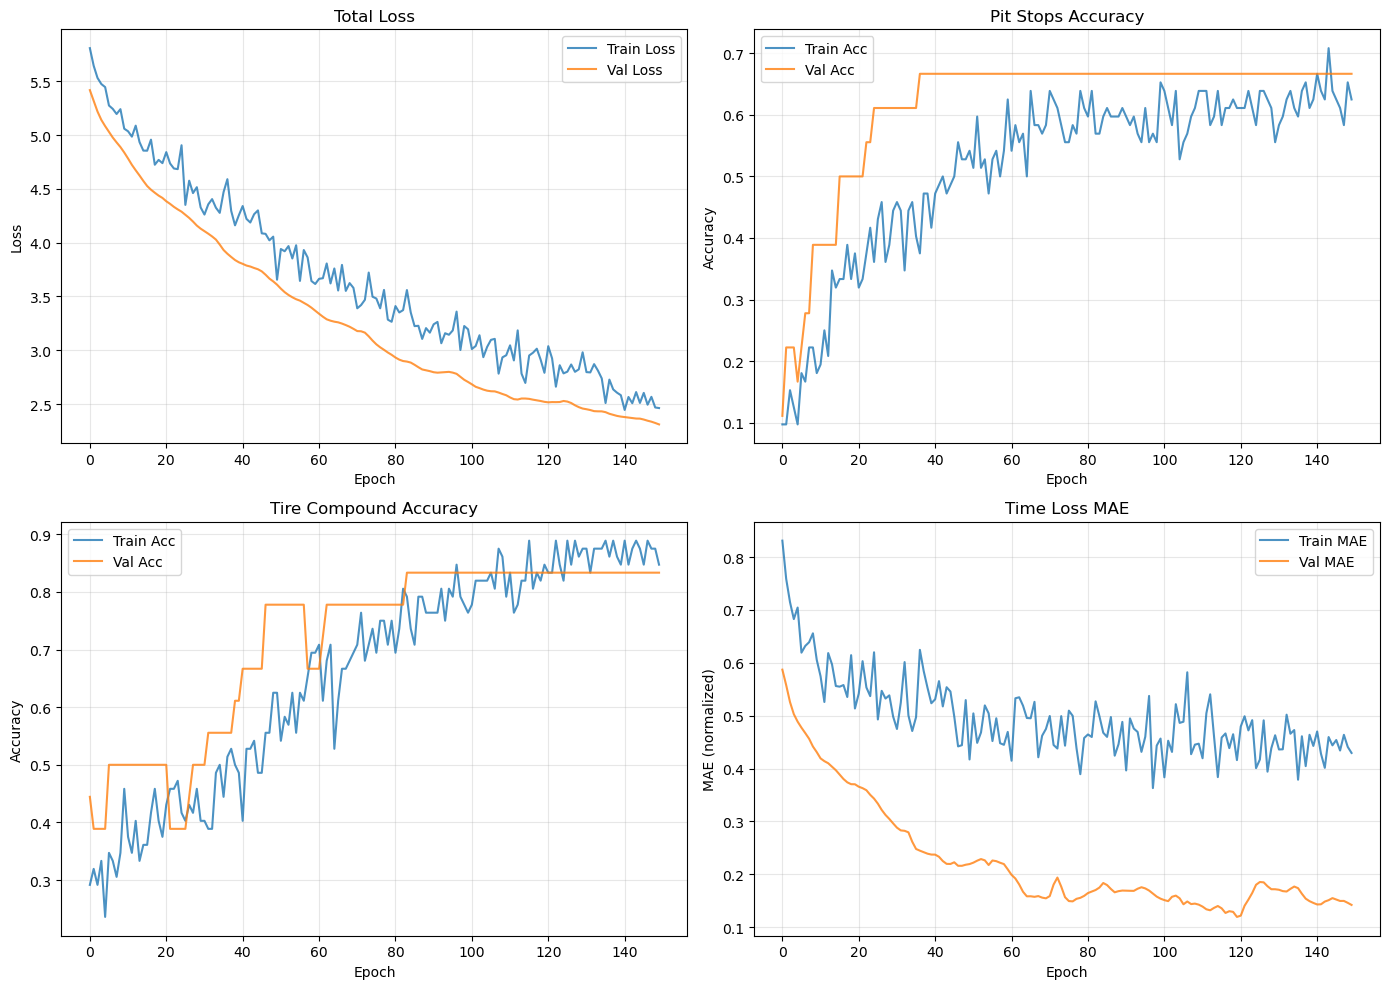

In [9]:
print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
 
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# Loss
axes[0, 0].plot(history.history["loss"], label="Train Loss", alpha=0.8)
axes[0, 0].plot(history.history["val_loss"], label="Val Loss", alpha=0.8)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Total Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
 
# Stops accuracy
axes[0, 1].plot(history.history["stops_out_accuracy"], label="Train Acc", alpha=0.8)
axes[0, 1].plot(history.history["val_stops_out_accuracy"], label="Val Acc", alpha=0.8)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Pit Stops Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
 
# Tire accuracy
axes[1, 0].plot(history.history["tire_out_accuracy"], label="Train Acc", alpha=0.8)
axes[1, 0].plot(history.history["val_tire_out_accuracy"], label="Val Acc", alpha=0.8)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Tire Compound Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
 
# Time MAE
axes[1, 1].plot(history.history["time_out_mae"], label="Train MAE", alpha=0.8)
axes[1, 1].plot(history.history["val_time_out_mae"], label="Val MAE", alpha=0.8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("MAE (normalized)")
axes[1, 1].set_title("Time Loss MAE")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("training_history_improved.png", dpi=150, bbox_inches="tight")
print("\nSaved training history plot: training_history_improved.png")
 
# Final validation metrics
val_results = model.evaluate(X_val, y_val, verbose=0)
print("\n" + "="*60)
print("FINAL VALIDATION METRICS")
print("="*60)
print(f"Total Loss: {val_results[0]:.4f}")
print(f"Stops Accuracy: {val_results[4]:.2%}")
print(f"Tire Accuracy: {val_results[5]:.2%}")
print(f"Time MAE (normalized): {val_results[6]:.4f}")

## Save model + preprocessing

In [10]:
joblib.dump({
    "team_le": team_le,
    "track_le": track_le,
    "start_le": start_le,
    "tire_le": tire_le,
    "stops_le": stops_le,
    "seq_mean": seq_mean,
    "seq_std": seq_std,
    "num_cols": NUM_COLS,
    "weather_features": WEATHER_FEATURES,
    "max_timesteps": X_seq.shape[1],
    "y_time_mean": float(y_time_mean),
    "y_time_std": float(y_time_std),
}, PREPROC_FILE)
 
print(f"\nSaved model: {MODEL_FILE}")
print(f"Saved preprocessing: {PREPROC_FILE}")
print("\n✓ Training complete!")



Saved model: multitask_strategy_model_improved.keras
Saved preprocessing: multitask_preprocessing_improved.joblib

✓ Training complete!


## Strategy simulation using the GRU model (top strategies + consistent stint breakdown)

In [11]:
def encode_with_unknown(le, val):
    """Encode with fallback to first class if unknown"""
    val = str(val)
    if val in set(le.classes_):
        return int(le.transform([val])[0])
    return 0  # Fallback to first class
 
def estimate_track_pit_loss_map():
    """Estimate pit loss time per track from historical data"""
    session_to_track, _, _ = load_session_maps()
    out = {}
    
    if not DATA_DIR.exists():
        return out
        
    for pf in sorted(DATA_DIR.glob("pit_session_*.csv")):
        sid = parse_session_key(pf)
        if sid is None:
            continue
        track = str(session_to_track.get(sid, "UNKNOWN_TRACK"))
        p = safe_read_csv(pf)
        if p.empty:
            continue
        
        dcol = next((c for c in ["pit_duration", "duration", "pit_time"] 
                    if c in p.columns), None)
        if dcol:
            d = pd.to_numeric(p[dcol], errors="coerce").dropna()
            if len(d):
                out[track] = float(np.median(d) + 15.0)
    return out
 
def forecast_to_sequence_and_summary(forecast_df, weather_features, max_timesteps, seq_mean, seq_std):
    """Convert forecast data to normalized sequence and summary stats"""
    f = forecast_df.copy()
    
    for c in weather_features:
        if c not in f.columns:
            f[c] = np.nan
        f[c] = pd.to_numeric(f[c], errors="coerce")
    
    f = f[weather_features].ffill().bfill().fillna(0.0)
    
    # Pad and normalize consistently with training
    seq = pad_sequences([f.values.astype("float32")], 
                       maxlen=max_timesteps, 
                       padding="post", 
                       dtype="float32")
    seq = (seq - seq_mean) / seq_std
    
    summary = {
        "air_temp_mean": float(f["air_temperature"].mean()),
        "track_temp_mean": float(f["track_temperature"].mean()),
        "humidity_mean": float(f["humidity"].mean()),
        "rain_minutes_ratio": float((f["rainfall"] > 0).mean()),
        "wind_speed_mean": float(f["wind_speed"].mean()),
    }
    return seq, summary
 
# ============================================================================
# STRATEGY GENERATION
# ============================================================================
def split_laps(total_laps, n_stints):
    """Split total laps across stints as evenly as possible"""
    b = total_laps // n_stints
    r = total_laps % n_stints
    return [b + (1 if i < r else 0) for i in range(n_stints)]
 
def build_candidates(start_comp, max_stops=3, wet=False):
    """Generate all valid strategy candidates"""
    pool = VALID_COMPOUNDS if wet else DRY_COMPOUNDS
    start_comp = str(start_comp).upper()
    if start_comp not in pool:
        start_comp = "MEDIUM" if "MEDIUM" in pool else pool[0]
 
    cands = []
    for s in range(max_stops + 1):
        if s == 0:
            cands.append([start_comp])
        else:
            for seq in product(pool, repeat=s):
                full = [start_comp] + list(seq)
                # Skip strategies with no compound changes
                if len(set(full)) == 1:
                    continue
                cands.append(full)
    return cands

In [16]:
import numpy as np

def simulate_with_gru(model, pre, race_context, seq_input, weather_summary, compounds, pit_loss):
    """
    Simulate a race strategy using the GRU model predictions
    
    Combines:
    - Physics-based lap time simulation (degradation, compound differences)
    - GRU model predictions for strategy validation
    - Pit stop time loss
    """
    # Encode categorical features
    team_id = encode_with_unknown(pre["team_le"], race_context["team_name"])
    track_id = encode_with_unknown(pre["track_le"], race_context["track_name"])
    start_id = encode_with_unknown(pre["start_le"], race_context["starting_compound"])
 
    # Prepare numerical features (must match training normalization)
    num_vec = np.array([[
        race_context["starting_position"],
        weather_summary["air_temp_mean"],
        weather_summary["track_temp_mean"],
        weather_summary["humidity_mean"],
        weather_summary["rain_minutes_ratio"],
        weather_summary["wind_speed_mean"]
    ]], dtype="float32")
 
    # Get model predictions
    preds = model.predict({
        "weather_seq": seq_input,
        "team_in": np.array([team_id], dtype=np.int32),
        "track_in": np.array([track_id], dtype=np.int32),
        "start_comp_in": np.array([start_id], dtype=np.int32),
        "num_in": num_vec,
    }, verbose=0)
    
    # === FIX: Safely unpack predictions whether Keras returns a dict or list ===
    if isinstance(preds, dict):
        # Extract values (NumPy arrays) instead of dictionary keys
        p_stops, p_tire, p_time = list(preds.values())
    else:
        p_stops, p_tire, p_time = preds
 
    # === PHYSICS-BASED LAP TIME SIMULATION ===
    total_laps = int(race_context["race_laps"])
    
    # Base lap time estimation (track + weather effects)
    base_lap = (92.0 + 
                0.08 * max(weather_summary["track_temp_mean"] - 35.0, 0) +
                6.0 * weather_summary["rain_minutes_ratio"])
 
    # Compound performance deltas (relative to MEDIUM)
    comp_delta = {
        "SOFT": -0.30,      # Faster
        "MEDIUM": 0.0,      # Baseline
        "HARD": 0.22,       # Slower
        "INTERMEDIATE": 1.2, # Much slower in dry
        "WET": 2.0          # Much slower in dry
    }
    
    # Degradation per lap (compounds wear differently)
    degr = {
        "SOFT": 0.040,
        "MEDIUM": 0.025,
        "HARD": 0.018,
        "INTERMEDIATE": 0.032,
        "WET": 0.042
    }
 
    # Simulate each stint
    stint_laps = split_laps(total_laps, len(compounds))
    detailed =[]
    sim_time = 0.0
    
    for i, (c, L) in enumerate(zip(compounds, stint_laps), start=1):
        c = str(c).upper()
        lap_times =[]
        
        for lap_in_stint in range(L):
            # Lap time = base + compound effect + degradation
            lap_t = (base_lap + 
                    comp_delta.get(c, 0.0) + 
                    degr.get(c, 0.025) * lap_in_stint)
            is_dry_tire = c in ["SOFT", "MEDIUM", "HARD"]
            if wet and is_dry_tire:
                lap_t += 15.0  # Dry tires are useless in real rain
            lap_times.append(lap_t)
        
        stint_sec = float(np.sum(lap_times))
        sim_time += stint_sec
        
        detailed.append({
            "stint": i,
            "compound": c,
            "laps": L,
            "predicted_stint_time_sec": stint_sec
        })
        
        # Add pit stop time (except after last stint)
        if i < len(compounds):
            sim_time += pit_loss
 
    # === GRU MODEL CALIBRATION ===
    # Extract GRU predictions
    gru_time_norm = float(p_time[0][0])
    gru_time_loss = np.expm1(gru_time_norm * pre["y_time_std"] + pre["y_time_mean"])
    
    pred_stops_class = int(np.argmax(p_stops[0]))
    pred_stops_val = int(pre["stops_le"].inverse_transform([pred_stops_class])[0])
    
    # Penalty for strategies that deviate from model's preferred stop count
    stop_mismatch_penalty = abs((len(compounds) - 1) - pred_stops_val) * 5.0
    
    # Final time: weighted blend of simulation + GRU calibration
    total = sim_time + 0.25 * gru_time_loss + stop_mismatch_penalty
    
    return {
        "strategy": " → ".join(compounds),
        "stops": len(compounds) - 1,
        "predicted_total_time_sec": total,
        "pit_loss_per_stop_sec": pit_loss,
        "gru_predicted_stops": pred_stops_val,
        "gru_tire_class": pre["tire_le"].inverse_transform([int(np.argmax(p_tire[0]))])[0],
        "gru_time_loss_sec": gru_time_loss,
        "stints": detailed,
    }

In [20]:
print("="*70)
print("F1 STRATEGY RECOMMENDER - IMPROVED MODEL")
print("="*70)

# Create example input files if missing
if not Path(RACE_CONTEXT_FILE).exists():
    print(f"\nCreating example {RACE_CONTEXT_FILE}...")
    pd.DataFrame([{
        "team_name": "Ferrari",
        "track_name": "Imola",
        "starting_position": 4,
        "starting_compound": "MEDIUM",
        "race_laps": 63
    }]).to_csv(RACE_CONTEXT_FILE, index=False)

if not Path(FORECAST_FILE).exists():
    print(f"Creating example {FORECAST_FILE}...")
    pd.DataFrame([
        {"date":"2026-05-17T13:00:00Z","air_temperature":22.1,"track_temperature":37.5,"humidity":44,"rainfall":0.0,"wind_speed":2.9},
        {"date":"2026-05-17T13:10:00Z","air_temperature":22.4,"track_temperature":38.1,"humidity":43,"rainfall":0.0,"wind_speed":3.1},
        {"date":"2026-05-17T13:20:00Z","air_temperature":22.8,"track_temperature":38.9,"humidity":41,"rainfall":0.0,"wind_speed":2.7},
    ]).to_csv(FORECAST_FILE, index=False)

# Load model and preprocessing
print(f"\nLoading model from {MODEL_FILE}...")
pre = joblib.load(PREPROC_FILE)
gru_model = keras.models.load_model(MODEL_FILE)

print(f"Loading pit loss data...")
pit_loss_map = estimate_track_pit_loss_map()

# Load race context and forecast
print(f"\nLoading race context from {RACE_CONTEXT_FILE}...")
rc = pd.read_csv(RACE_CONTEXT_FILE).iloc[0].to_dict()
fc = pd.read_csv(FORECAST_FILE)

# Parse and validate race context
rc["team_name"] = str(rc.get("team_name", "UNKNOWN_TEAM"))
rc["track_name"] = str(rc.get("track_name", "UNKNOWN_TRACK"))
rc["starting_position"] = float(rc.get("starting_position", 10))
rc["starting_compound"] = str(rc.get("starting_compound", "MEDIUM")).upper()
rc["race_laps"] = int(rc.get("race_laps", 60))

print("\n" + "-"*70)
print("RACE CONTEXT")
print("-"*70)
print(f"Team: {rc['team_name']}")
print(f"Track: {rc['track_name']}")
print(f"Starting Position: P{rc['starting_position']:.0f}")
print(f"Starting Tire: {rc['starting_compound']}")
print(f"Race Laps: {rc['race_laps']}")

# Process weather forecast
seq_input, ws = forecast_to_sequence_and_summary(
    fc, 
    pre["weather_features"], 
    pre["max_timesteps"],
    pre["seq_mean"],
    pre["seq_std"]
)

print("\n" + "-"*70)
print("WEATHER FORECAST")
print("-"*70)
print(f"Air Temperature: {ws['air_temp_mean']:.1f}°C")
print(f"Track Temperature: {ws['track_temp_mean']:.1f}°C")
print(f"Humidity: {ws['humidity_mean']:.1f}%")
print(f"Rain Probability: {ws['rain_minutes_ratio']:.1%}")
print(f"Wind Speed: {ws['wind_speed_mean']:.1f} m/s")

# Determine if wet conditions
wet = ws["rain_minutes_ratio"] > 0.2
if wet:
    print("\n⚠️  WET CONDITIONS DETECTED - Including wet tires in strategy pool")

# Generate candidate strategies
print(f"\n" + "-"*70)
print("EVALUATING STRATEGIES")
print("-"*70)
cands = build_candidates(rc["starting_compound"], max_stops=3, wet=wet)
print(f"Generated {len(cands)} candidate strategies...")

# Get pit loss for this track
pit_loss = float(pit_loss_map.get(rc["track_name"], DEFAULT_PIT_LOSS))
print(f"Estimated pit loss: {pit_loss:.1f}s per stop")

# Simulate all candidates
print("\nRunning simulations...")
results = [
    simulate_with_gru(gru_model, pre, rc, seq_input, ws, c, pit_loss) 
    for c in cands
]

# Rank results
res_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "stints"} 
    for r in results
]).sort_values("predicted_total_time_sec").reset_index(drop=True)

best = float(res_df.loc[0, "predicted_total_time_sec"])
res_df["delta_to_best_sec"] = res_df["predicted_total_time_sec"] - best

# Display top 10
show = res_df.head(10).copy()
show["predicted_total_time"] = show["predicted_total_time_sec"].apply(format_time)
show["delta_to_best"] = show["delta_to_best_sec"].map(lambda x: f"+{x:.2f}s" if x > 0 else "BEST")

print("\n" + "="*70)
print("TOP 10 STRATEGIES")
print("="*70)
print(show[["strategy", "stops", "predicted_total_time", "delta_to_best", "pit_loss_per_stop_sec"]].to_string(index=False))

# Show best strategy details
best_strategy_name = res_df.loc[0, "strategy"]
best_obj = next(r for r in results if r["strategy"] == best_strategy_name)

print("\n" + "="*70)
print("🏆 RECOMMENDED STRATEGY")
print("="*70)
print(f"Strategy: {best_obj['strategy']}")
print(f"Pit Stops: {best_obj['stops']}")
print(f"Predicted Total Time: {format_time(best_obj['predicted_total_time_sec'])}")
print(f"Assumed Pit Loss: {best_obj['pit_loss_per_stop_sec']:.1f}s per stop")
print(f"\nGRU Model Insights:")
print(f"  Preferred Stops: {best_obj['gru_predicted_stops']}")
print(f"  Predicted Tire: {best_obj['gru_tire_class']}")

print("\n" + "-"*70)
print("STINT BREAKDOWN")
print("-"*70)
for st in best_obj["stints"]:
    print(f"  Stint {st['stint']}: {st['compound']:12s} | "
          f"{st['laps']:2d} laps | "
          f"{format_time(st['predicted_stint_time_sec'])}")

print("\n" + "="*70)
print("✓ Analysis complete!")
print("="*70)

F1 STRATEGY RECOMMENDER - IMPROVED MODEL

Loading model from multitask_strategy_model_improved.keras...
Loading pit loss data...

Loading race context from race_context_input.csv...

----------------------------------------------------------------------
RACE CONTEXT
----------------------------------------------------------------------
Team: Ferrari
Track: Imola
Starting Position: P4
Starting Tire: MEDIUM
Race Laps: 63

----------------------------------------------------------------------
WEATHER FORECAST
----------------------------------------------------------------------
Air Temperature: 19.1°C
Track Temperature: 22.3°C
Humidity: 92.9%
Rain Probability: 78.6%
Wind Speed: 4.3 m/s

⚠️  WET CONDITIONS DETECTED - Including wet tires in strategy pool

----------------------------------------------------------------------
EVALUATING STRATEGIES
----------------------------------------------------------------------
Generated 153 candidate strategies...
Estimated pit loss: 45.3s per stop

